# Option Pricer Analysis

This notebook reads the results produced by the C++ pricer and visualises:
- Monte Carlo price convergence toward the Black-Scholes price as the number of simulations grows
- The error between MC and BS as a function of numSims
- Timing comparison between the two methods

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV produced by the C++ pricer.
# The path is relative to this notebook's location (python/).
df = pd.read_csv('../output/results.csv')
print(df)

   numSims  mcPrice  bsPrice     error   timeMs
0      100  7.26933  8.02135 -0.752026   0.0297
1     1000  8.94025  8.02135  0.918899   0.0878
2    10000  8.14388  8.02135  0.122531   0.4500
3   100000  8.04888  8.02135  0.027530   7.4193
4  1000000  8.03755  8.02135  0.016198  64.9274


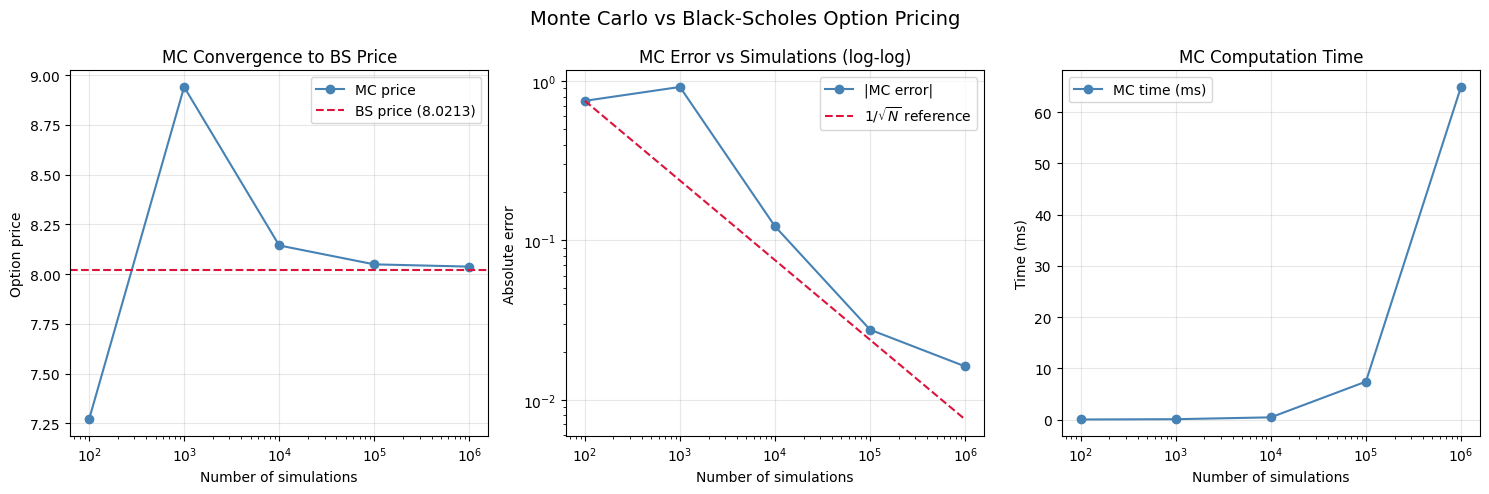

Plot saved to output/convergence.png


In [2]:
bs_price = df['bsPrice'].iloc[0]  # same for every row

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Monte Carlo vs Black-Scholes Option Pricing', fontsize=14)

# --- Plot 1: MC price convergence to BS price ---
ax1 = axes[0]
ax1.semilogx(df['numSims'], df['mcPrice'], 'o-', color='steelblue', label='MC price')
ax1.axhline(y=bs_price, color='crimson', linestyle='--', label=f'BS price ({bs_price:.4f})')
ax1.set_xlabel('Number of simulations')
ax1.set_ylabel('Option price')
ax1.set_title('MC Convergence to BS Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Absolute error vs numSims on log-log scale ---
# On a log-log plot, a 1/sqrt(N) relationship appears as a straight line with slope -0.5.
# We overlay the theoretical 1/sqrt(N) line to verify our MC is behaving correctly.
ax2 = axes[1]
abs_error = df['error'].abs()
ax2.loglog(df['numSims'], abs_error, 'o-', color='steelblue', label='|MC error|')

# Theoretical 1/sqrt(N) reference line, scaled to pass through the first point
N = df['numSims'].values
scale = abs_error.iloc[0] * np.sqrt(N[0])
ax2.loglog(N, scale / np.sqrt(N), '--', color='crimson', label=r'$1/\sqrt{N}$ reference')

ax2.set_xlabel('Number of simulations')
ax2.set_ylabel('Absolute error')
ax2.set_title('MC Error vs Simulations (log-log)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: Timing ---
ax3 = axes[2]
ax3.semilogx(df['numSims'], df['timeMs'], 'o-', color='steelblue', label='MC time (ms)')
ax3.set_xlabel('Number of simulations')
ax3.set_ylabel('Time (ms)')
ax3.set_title('MC Computation Time')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to output/convergence.png')

In [3]:
# Summary statistics
print(f'Black-Scholes price:          {bs_price:.6f}')
print(f'MC price (1,000,000 sims):    {df["mcPrice"].iloc[-1]:.6f}')
print(f'Final error:                  {df["error"].iloc[-1]:.6f}')
print(f'Final error (%):              {100 * df["error"].iloc[-1] / bs_price:.4f}%')

Black-Scholes price:          8.021350
MC price (1,000,000 sims):    8.037550
Final error:                  0.016198
Final error (%):              0.2019%
